In [430]:
import qeg_nmr_qua as qnmr

from qualang_tools.units import unit
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import jn
import time

u = unit(coerce_to_integer=True)

# Settings

In [444]:
# create base settings object for experiments
settings = qnmr.ExperimentSettings(
    n_avg=2,
    pulse_length=1.24 * u.us,
    pulse_amplitude=0.465,  # amplitude is 0.5*Vpp
    pulse_shape="square",
    pulse_rise_fall=0.0,  # 0% rise/fall time
    rotation_angle=141,  # degrees
    thermal_reset=4 * u.s,
    center_freq=282.1901 * u.MHz,
    offset_freq=19140 * u.Hz,
    readout_delay=20 * u.us,
    dwell_time=4 * u.us,
    readout_start=0 * u.us,
    readout_end=256 * u.us,
    save_dir=Path.home() / "Dropbox/QEG/NMR/RawData" / "alt32"
)
rho0 = "Z"
cfg = qnmr.cfg_from_settings(settings)

# Tests

In [447]:
t0 = 5.0 * u.us
# ----- c2=0.0 -----
rho0 = "Z"
# a,b,c,u0,v,w = [5.8473e-03, -1.1341e-02, 1.1165e-02, -4.7430e-02, 1.2494e-01, 1.2248e-01] # no disorder
# a,b,c,u0,v,w = [5.5087e-03, -1.0372e-02, 1.9857e-02, -7.9646e-02, 8.8294e-02, 8.5725e-02] # disorder c1=.01
# a,b,c,u0,v,w = [9.4893e-03, -7.9019e-03, 1.3554e-02, -6.2326e-02, 1.1315e-01, 1.1072e-01] # alternate j0
# a,b,c,u0,v,w = [1.0529e-02, -3.6724e-03, 1.3512e-02, -1.2673e-01, 5.8570e-02, 5.6462e-02] # NN2
# a,b,c,u0,v,w = [-0.002218, -0.002218, 0.004436, 0.000499, -0.000758, -0.00049] # avg_ham min_blk Alt32 disorder 0 (2x stddev)
# a,b,c,u0,v,w = [-0.00065, -0.004453, 0.005833, -0.109047, 0.084428, 0.083205] # avg_ham min_blk Alt32 disorder 0
# a,b,c,u0,v,w = [0.001119, -0.003709, 0.013046, -0.092007, 0.083086, 0.080899] # avg_ctrl min_blk Alt32 disorder 1
# a,b,c,u0,v,w = [-0.000823, 0.0044, -0.001431, 0.001493, -0.022808, -0.029484] # avg_ctrl min blk Alt32 disorder 2
# a,b,c,u0,v,w = [-0.007883, -0.017547, 0.009726, -0.108685, 0.109769, 0.108703] # avg_ctrl min_blk Alt32 disorder 3
# a,b,c,u0,v,w = [-0.000572, 0.005853, -0.001259, 0.01965, -0.003595, -0.013071] # avg_Control min blk Alt32 disorder 4
a,b,c,u0,v,w =[-0.000519, 0.003875, -0.00149, 0.007649, -0.012116, -0.018712] # avg_Control min blk Alt32 disorder 5


# a,b,c,u0,v,w = [0,0,0,0,0,0]

# # ----- c2=0.025 -----
# rho0 = "X"
# a,b,c,u0,v,w = [2.8408e-03, -1.0908e-02, -4.1878e-05 ,  6.0531e-03 ,  1.9437e-02 ,  6.3797e-02 ]

# ----- c2 =-.01 -----
# a,b,c,u0,v,w = [2.1996e-03, 1.2896e-02, 1.5474e-03, -4.6523e-02, 3.3100e-02, 7.8114e-03]
# c2=-.01; a,b,c,u0,v,w=[0,0,0,0,-c2,c2]

tp = settings.pulse_length
t1  = t0*(1+c-v+w)  - tp/2
t1p = t0*(1-c-v+w)  - tp/2
t2  = t0*(1+b-u0+v) - tp
t2p = t0*(1-b-u0+v) - tp
t3  = t0*(1-a+u0-w) - tp/2
t3p = t0*(1+a+u0-w) - tp/2

# Sequence pattern for engineering H
alt32_phases = np.array([0,90,90,0,      0,90,90,0,      180,270,270,180,  180,270,270,180,
                         90,180,180,90,  90,180,180,90,  270,0,0,270,      270,0,0,270])
alt32_delays = np.array([t1,  t2,  2*t3,  t2p, t1p +
                         t1p, t2,  2*t3p, t2p, t1  +
                         t1,  t2p, 2*t3p, t2,  t1p +
                         t1p, t2p, 2*t3,  t2,  t1  +
                         t1,  t2,  2*t3,  t2p, t1p +
                         t1p, t2,  2*t3p, t2p, t1  +
                         t1,  t2p, 2*t3p, t2,  t1p +
                         t1p, t2p, 2*t3,  t2,  t1])
print(alt32_delays)

[4339.57 3680.55 9028.8  3641.8  8708.94 3680.55 9018.42 3641.8  8679.14
 3641.8  9018.42 3680.55 8708.94 3641.8  9028.8  3680.55 8679.14 3680.55
 9028.8  3641.8  8708.94 3680.55 9018.42 3641.8  8679.14 3641.8  9018.42
 3680.55 8708.94 3641.8  9028.8  3680.55 4339.57]


In [450]:
rho0 = "Z"
# time suspension
a,b,c,u0,v,w = [0,0,0,0,0,0]
# a,b,c,u0,v,w = [ 0.014315, -0.006273, 0.006572, -0.121232, 0.070232, 0.068898 ] # avg_Control min blk sandwich32 disorder 1
# a,b,c,u0,v,w = [0.023548, -0.007406, 0.014272, -0.112957, 0.066625, 0.064582]
# a,b,c,u0,v,w = [0.01295075, -0.00836785, 0.00781696, -0.13889865, 0.06403189, 0.06326623] #Boxing 1
# a,b,c,u0,v,w = [0.00907116, -0.00816212, 0.00582107, -0.13690523, 0.06228414, 0.06115118] #Boxing 2
# a,b,c,u0,v,w = [-0.004057, 0.000376, -0.001027, 0.03742, -0.009735, -0.016533] # avg_Control min blk sandwich32 disorder 2
# a,b,c,u0,v,w = [-0.000823, 0.0044, -0.001431, 0.001493, -0.022808, -0.029484] # avg_ctrl min blk Sandwich32 mixup
# a,b,c,u0,v,w = [0.017913, -0.005456, 0.007753, -0.158333, 0.047092, 0.046141] # avg_Control min blk sandwich32 disorder 3
# a,b,c,u0,v,w = [-0.002945, 0.002356, -0.001305, 0.030206, -0.005004, -0.014516] # avg_Control min blk sandwich32 disorder 4
a,b,c,u0,v,w =[-0.005508, 0.00061, -0.00129, 0.034363, -0.023224, -0.030242] # avg_Control min blk sandwich32 disorder 5

tp = settings.pulse_length
t1  = t0*(1+c-v+w)  - tp/2
t1p = t0*(1-c-v+w)  - tp/2
t2  = t0*(1+b-u0+v) - tp
t2p = t0*(1-b-u0+v) - tp
t3  = t0*(1-a+u0-w) - tp/2
t3p = t0*(1+a+u0-w) - tp/2

sandwich32_phases = np.array([0,90,90,0,    0,90,90,0,    90,180,180,90,    90,180,180,90,
                              270,0,0,270,  270,0,0,270,  180,270,270,180,  180,270,270,180])
sandwich32_delays = np.array([t1,  t2,  2*t3,  t2p, t1p +
                              t1p, t2,  2*t3p, t2p, t1  +
                              
                              t1,  t2,  2*t3,  t2p, t1p +
                              t1p, t2,  2*t3p, t2p, t1  +
                              t1,  t2p, 2*t3p, t2,  t1p +
                              t1p, t2p, 2*t3,  t2,  t1  +
                              
                              t1,  t2p, 2*t3p, t2,  t1p +
                              t1p, t2p, 2*t3,  t2,  t1])
print(sandwich32_delays)

[4338.46  3475.115 9461.13  3469.015 8702.72  3475.115 9350.97  3469.015
 8676.92  3475.115 9461.13  3469.015 8702.72  3475.115 9350.97  3469.015
 8676.92  3469.015 9350.97  3475.115 8702.72  3469.015 9461.13  3475.115
 8676.92  3469.015 9350.97  3475.115 8702.72  3469.015 9461.13  3475.115
 4338.46 ]


2026-06-30 21:17:20,204 - qm - INFO     - Performing health check
2026-06-30 21:17:20,222 - qm - INFO     - Cluster healthcheck completed successfully.
2026-06-30 21:17:21,411 - qm - INFO     - Clearing queue
2026-06-30 21:17:21,424 - qm - INFO     - Adding program to queue.


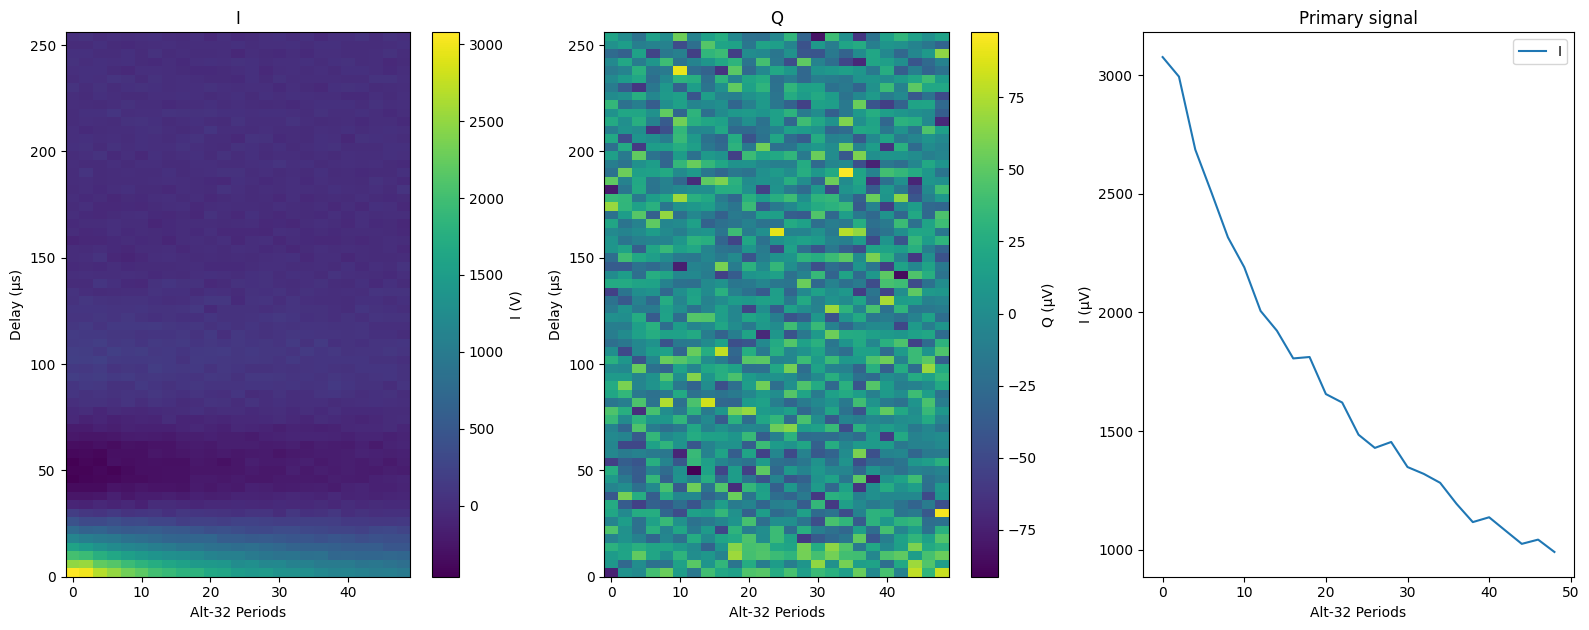

Progress: [##################################################] 100.0% (n=2/2) --> elapsed time: 100.51s
Progress: [##################################################] 100.0% (n=2/2) --> elapsed time: 101.07s
Acquisition finished. Close the plot window to continue.
Data saved successfully to folder: C:\Users\NMR Lab\Dropbox\QEG\NMR\RawData\alt32\experiment_0055


In [454]:
# define experiment object
expt = qnmr.Experiment2D(settings=settings, config=cfg)
expt.add_frame_change(angle=-3.85, elements=(settings.res_key, settings.helper_key))

# rotate to evolve X, Y, or Z state operator under DQ
if   rho0 == "X": expt.add_pulse(phase=[90, 270], element=settings.res_key, phase_cycle=True)
elif rho0 == "Y": expt.add_pulse(phase=[180, 0], element=settings.res_key, phase_cycle=True)
elif rho0 == "Z": pass
else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")
expt.add_delay(2.5*u.us)

# evolve
period_list = np.arange(0,50,2)
# expt.add_floquet_sequence(phases=alt32_phases, delays=alt32_delays, repetitions=period_list)
expt.add_floquet_sequence(phases=sandwich32_phases, delays=sandwich32_delays, repetitions=period_list)
# expt.add_floquet_sequence(phases=wei16_phases, delays=wei16_delays, repetitions=period_list)
expt.update_sweep_label("Alt-32 Periods")

# rotate back to measure X, Y, or Z observable
expt.add_delay(2.5 * u.us)
if   rho0 == "X": expt.add_pulse(phase=[270, 90], phase_cycle=True, element=settings.res_key)
elif rho0 == "Y": expt.add_pulse(phase=[0, 180], phase_cycle=True, element=settings.res_key)
elif rho0 == "Z": pass
else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")

# filter transients and measure
expt.add_delay(1 * u.ms)
expt.add_pulse(element=settings.res_key, phase=[90, 270], phase_cycle=True)
expt.add_measurement(phase=[0, 180], phase_cycle=True,)

expt.update_sweep_axis(period_list)

expt.execute_experiment()
# expt.remove_initial_delay(); expt.simulate_experiment()

In [ ]:
t0 = 5.0 * u.us
c2=0.025
a,b,c,u0,v,w = [0,0,0,0,-c2,c2]

tp = settings.pulse_length
t1  = t0*(1+c-v+w)  - tp/2
t1p = t0*(1-c-v+w)  - tp/2
t2  = t0*(1+b-u0+v) - tp
t2p = t0*(1-b-u0+v) - tp
t3  = t0*(1-a+u0-w) - tp/2
t3p = t0*(1+a+u0-w) - tp/2

# Sequence pattern for engineering H
wei16_phases = np.array([0,90,90,0,      0,90,90,0,      180,270,270,180,  180,270,270,180])
wei16_delays = np.array([t1,  t2,  2*t3,  t2p, t1p +
                         t1p, t2,  2*t3p, t2p, t1  +
                         t1,  t2p, 2*t3p, t2,  t1p +
                         t1p, t2p, 2*t3,  t2,  t1])

# Sweep

In [ ]:
rho0 = "Z"
sandwich32_phases = np.array([0,90,90,0,    0,90,90,0,    90,180,180,90,    90,180,180,90,
                              270,0,0,270,  270,0,0,270,  180,270,270,180,  180,270,270,180])
a,b,c=[0,0,0]

def calcsandwich32_delays(a,b,c,u0,v,w) :
    tp = settings.pulse_length
    t1  = t0*(1+c-v+w) - tp/2;     t2  = t0*(1+b-u0+v) - tp;     t3  = t0*(1-a+u0-w) - tp/2
    t1p = t0*(1-c-v+w) - tp/2;     t2p = t0*(1-b-u0+v) - tp;     t3p = t0*(1+a+u0-w) - tp/2

    sandwich32_delays = np.array([t1,  t2,  2*t3,  t2p, t1p +
                                t1p, t2,  2*t3p, t2p, t1  +
                                
                                t1,  t2,  2*t3,  t2p, t1p +
                                t1p, t2,  2*t3p, t2p, t1  +
                                t1,  t2p, 2*t3p, t2,  t1p +
                                t1p, t2p, 2*t3,  t2,  t1  +
                                
                                t1,  t2p, 2*t3p, t2,  t1p +
                                t1p, t2p, 2*t3,  t2,  t1])
    return sandwich32_delays

def brief_floquet() :
    # define experiment object
    expt = qnmr.Experiment2D(settings=settings, config=cfg)
    expt.add_frame_change(angle=-3.85, elements=(settings.res_key, settings.helper_key))

    # rotate to evolve X, Y, or Z state operator under DQ
    if   rho0 == "X": expt.add_pulse(phase=[90, 270], element=settings.res_key, phase_cycle=True)
    elif rho0 == "Y": expt.add_pulse(phase=[180, 0], element=settings.res_key, phase_cycle=True)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")
    expt.add_delay(2.5*u.us)

    # evolve
    period_list = np.arange(0,50,16)
    expt.add_floquet_sequence(phases=sandwich32_phases, delays=sandwich32_delays, repetitions=period_list)
    expt.update_sweep_label("Alt-32 Periods")

    # rotate back to measure X, Y, or Z observable
    expt.add_delay(2.5 * u.us)
    if   rho0 == "X": expt.add_pulse(phase=[270, 90], phase_cycle=True, element=settings.res_key)
    elif rho0 == "Y": expt.add_pulse(phase=[0, 180], phase_cycle=True, element=settings.res_key)
    elif rho0 == "Z": pass
    else: raise ValueError("Invalid operator choice. Must be 'X', 'Y', or 'Z'.")

    # filter transients and measure
    expt.add_delay(1 * u.ms)
    expt.add_pulse(element=settings.res_key, phase=[90, 270], phase_cycle=True)
    expt.add_measurement(phase=[0, 180], phase_cycle=True,)

    expt.update_sweep_axis(period_list)

    expt.execute_experiment()
    # expt.remove_initial_delay(); expt.simulate_experiment()

param_range = np.linspace(-.05, 0.05, 5)
for u0 in param_range:
    print(f"u = "+str(u0))

    for v in param_range:
        print(f"  v = "+str(v))

        for w in param_range:
            print(f"    w = "+str(w))

            sandwich32_delays = calcsandwich32_delays(a,b,c,u0,v,w)
            print(sandwich32_delays)
            brief_floquet()
            

# Data Analysis

In [455]:
class Test:
    def __init__(self, name, id, length, color=None):
        self.name   = name    # String describing the experiment
        self.id     = id      # Stores experiment ID
        self.length = length  # length of 1 period in microseconds
        self.color  = color

# ----- c1=c2=0 -----
tests = [
        Test("Wei16 Unopt", 7, 24*5),
        Test("WeiAlt32 Unopt", 8, 48*5),
        Test("Sandwich32 unopt", 31, 48*5),


        # Test("WeiAlt32 min_blk", 5, 48*5),
        #  Test("WeiAlt32 min_blk + disorder", 11, 48*5),
        #  Test("WeiAlt32 min_blk J0=32.8", 12, 48*5),
        #  Test("WeiAlt32 Opt c2=-.01", 9, 48*5),
        #  Test("WeiAlt32 Opt NN2", 14, 48*5),
        #  Test("Avg_ctrl WeiAlt32 min_blk avg disorder 0 (2x stddev)", 20, 48*5),
         Test("Avg_ctrl WeiAlt32 min_blk avg disorder 1", 33, 48*5),
        #  Test("Avg_ctrl WeiAlt32 min_blk", 30, 48*5),
        #  Test("Sandwich32 min_blk avg ham", 28, 48*5),
        
        
        
        # Test("Sandwich32 min_blk avg disorder", 32, 48*5), 
        #  Test("Sandwich32 opt Boxing 1", 36, 48*5),
        #  Test("Sandwich32 opt Boxing 2", 37, 48*5),
         Test("Avg_ctrl Sandwich32 min_blk disorder 1", 33, 48*5),

         Test("Avg_ctrl WeiAlt32 min_blk disorder N=5", 39, 48*5),
         Test("Avg_ctrl Sandwich32 min_blk disorder N=5", 40, 48*5),
         Test("Avg_ctrl WeiAlt32 min_blk disorder NN2", 42, 48*5),
        #  Test("Avg_ctrl Sandwich32 min_blk mixup", 41, 48*5),
         Test("Avg_ctrl Sandwich32 min_blk disorder NN2", 43, 48*5),
         Test("Avg_ctrl WeiAlt32 min_blk disorder N=7", 52, 48*5),
         Test("Avg_ctrl Sandwich32 min_blk disorder N=7", 53, 48*5),
         Test("Avg_ctrl WeiAlt32 min_blk disorder N=9", 54, 48*5),
         Test("Avg_ctrl Sandwich32 min_blk disorder N=9", 55, 48*5),
        ]

# # ----- c2=-0.01 -----
# tests = [Test("WeiAlt32 Optimized c2=-.01", 9, 48*5),
#          Test("WeiAlt32 Unopt", 10, 48*5),
#         ]

# # ----- c2=0.025 -----
# tests = [Test("WeiAlt32, c2=0.025 opt", 17, 48*5),
#          Test("Wei16, c2=0.025 opt", 18, 24*5),
#          ]

Expt = Wei16 Unopt -> tau = 3335.582μs
1.014111575012753 3335.5820797619936 0.7239743769654482
Expt = WeiAlt32 Unopt -> tau = 8998.383μs
1.0031402798577178 8998.383244045557 0.6049811283257824
Expt = Sandwich32 unopt -> tau = 9093.618μs
1.0112202218099386 9093.618442901821 0.6295355110060359
Expt = Avg_ctrl WeiAlt32 min_blk avg disorder 1 -> tau = 5912.368μs
0.9984452718146991 5912.367850672926 0.6796389532442771
Expt = Avg_ctrl Sandwich32 min_blk disorder 1 -> tau = 5912.368μs
0.9984452718146991 5912.367850672926 0.6796389532442771
Expt = Avg_ctrl WeiAlt32 min_blk disorder N=5 -> tau = 8339.389μs
1.005192885554 8339.389271508779 0.6132256280306091
Expt = Avg_ctrl Sandwich32 min_blk disorder N=5 -> tau = 8351.141μs
1.008381155799725 8351.141497923947 0.6612941261143715
Expt = Avg_ctrl WeiAlt32 min_blk disorder NN2 -> tau = 5643.108μs
0.9990284285994842 5643.107600727821 0.6766350201738915
Expt = Avg_ctrl Sandwich32 min_blk disorder NN2 -> tau = 6302.501μs
0.9959043753202498 6302.501085

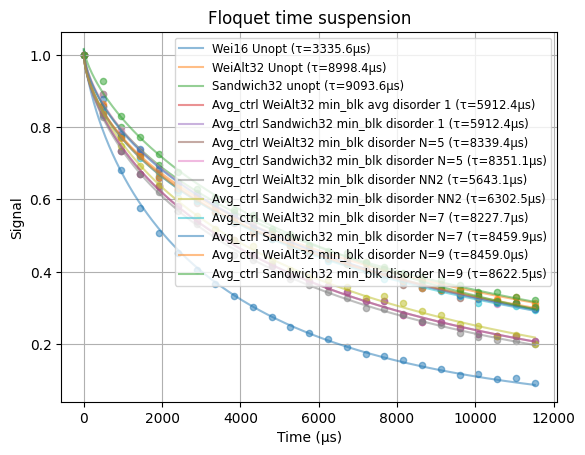

In [456]:
def stretched_exp(x, A, tau, beta):
    return A* np.exp(-(x / tau) ** beta)

for test in tests:
    data_path = settings.save_dir / f"experiment_{test.id:04d}/data.json"
    with open(data_path, "r") as f: data_dict = json.load(f)

    re = np.array(data_dict["I_data"]) * 1e6
    periods = np.array(data_dict["sweep_axis"])
    signal = re[:, 0]/re[0,0]

    time = periods * test.length
    mask = signal > 0
    x, y = time[mask], signal[mask]
    if len(x) < 3:
        print(f"Warning: insufficient positive data for experiment {test.id}, skipping")
        continue

    popt, _ = curve_fit(stretched_exp, x, y, p0=[1.0, 1000, 1.3], maxfev=10000)
    amplitude_fit, tau_fit, beta_fit = popt

    x_fit = np.linspace(min(time), max(time), 500)
    y_fit = stretched_exp(x_fit, *popt)

    plt.scatter(time, signal, s=20, alpha=.5, c=test.color)
    plt.plot(x_fit, y_fit, c=test.color, alpha=.5, label=f"{test.name} (τ={tau_fit:.1f}μs)")
    print(f"Expt = {test.name} -> tau = {tau_fit:.3f}μs")
    print(*popt)

plt.title("Floquet time suspension")
plt.xlabel("Time (μs)")
plt.ylabel("Signal")
plt.legend(loc="upper right", fontsize="small", ncol=1)
plt.grid(True)

u = -0.05
  v = -0.05
    w = -0.05
1
Expt = WeiAlt32, c2=0.025 opt -> tau = 9068.406μs
1.0000663320601315 9068.40605520544 0.6486146681062548
    w = -0.025
2
Expt = WeiAlt32, c2=0.025 opt -> tau = 9412.103μs
1.0000547916768372 9412.10329214948 0.6307153208510062
    w = 0.0
3
Expt = WeiAlt32, c2=0.025 opt -> tau = 9546.863μs
1.0000180434080186 9546.86274613494 0.6216738861650412
    w = 0.02500000000000001
4
Expt = WeiAlt32, c2=0.025 opt -> tau = 9386.512μs
0.9999930441669808 9386.51185795448 0.6375761647480227
    w = 0.05
5
Expt = WeiAlt32, c2=0.025 opt -> tau = 9443.507μs
1.000084982384424 9443.507304124065 0.6380429058433145
  v = -0.025
    w = -0.05
6
Expt = WeiAlt32, c2=0.025 opt -> tau = 9087.773μs
0.9999252280282234 9087.773277303277 0.6122637259876552
    w = -0.025
7
Expt = WeiAlt32, c2=0.025 opt -> tau = 9403.196μs
1.0000361134521258 9403.196315482752 0.6201713077016923
    w = 0.0
8
Expt = WeiAlt32, c2=0.025 opt -> tau = 9386.609μs
1.0000421336211176 9386.609482943797 0.

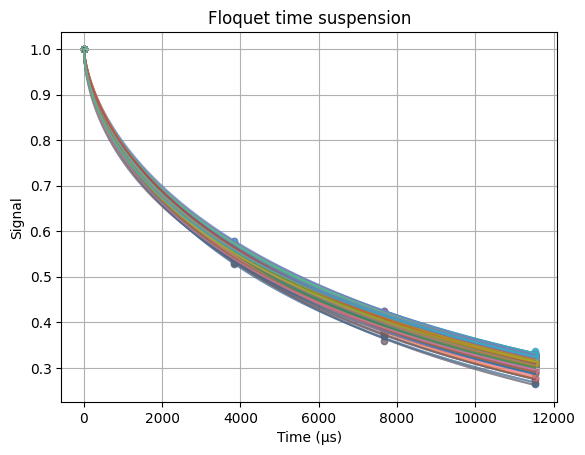

In [428]:
import matplotlib
matplotlib.use('inline')
%matplotlib inline
import matplotlib.pyplot as plt

def stretched_exp(x, A, tau, beta):
    return A* np.exp(-(x / tau) ** beta)

all_taus=[]
all_params=[]

def plotid(id):
    data_path = settings.save_dir / f"experiment_{id:04d}/data.json"
    with open(data_path, "r") as f: data_dict = json.load(f)

    re = np.array(data_dict["I_data"]) * 1e6
    periods = np.array(data_dict["sweep_axis"])
    signal = re[:, 0]/re[0,0]

    time = periods * 48*5
    mask = signal > 0
    x, y = time[mask], signal[mask]
    if len(x) < 3:
        print(f"Warning: insufficient positive data for experiment {test.id}, skipping")

    popt, _ = curve_fit(stretched_exp, x, y, p0=[1.0, 1000, 1.3], maxfev=10000)
    amplitude_fit, tau_fit, beta_fit = popt

    x_fit = np.linspace(min(time), max(time), 500)
    y_fit = stretched_exp(x_fit, *popt)

    all_taus.append(tau_fit)
    all_params.append([u0,v,w])
    
    plt.scatter(time, signal, s=20, alpha=.5, c=test.color)
    plt.plot(x_fit, y_fit, c=test.color, alpha=.5, label=f"{u0},{v},{w} (τ={tau_fit:.1f}μs)")
    print(f"Expt = {test.name} -> tau = {tau_fit:.3f}μs")
    print(*popt)

param_range = np.linspace(-.05, 0.05, 5)
i=0
for u0 in param_range:
    print(f"u = "+str(u0))

    for v in param_range:
        print(f"  v = "+str(v))

        for w in param_range:
            print(f"    w = "+str(w))
            i += 1
            print(i)
            plotid(i)
    


plt.title("Floquet time suspension")
plt.xlabel("Time (μs)")
plt.ylabel("Signal")
# plt.legend(loc="upper right", fontsize="small", ncol=1)
plt.grid(True)

In [426]:
plt.close('all')

In [420]:
np.max([all_taus])

9843.465546591324

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib widget
# Example:
# all_taus = np.array([...])          # Shape (N,)
# all_params = np.array([...])        # Shape (N, 3)

all_taus = np.array(all_taus)
all_params = np.array(all_params)

# Extract coordinates
u0 = all_params[:, 0]
v = all_params[:, 1]
w = all_params[:, 2]

# Normalize tau from 7000 -> 0 and 10000 -> 1
tau_norm = np.clip((all_taus - 9500) / (9800 - 9500), 0, 1)

# Marker sizes (adjust these numbers to taste)
sizes = 15 + 85*2 * tau_norm      # Size ranges from 5 to 100

# Create RGBA colors (black with varying alpha)
colors = np.zeros((len(all_taus), 4))
colors[:, 3] = .4+.6*tau_norm        # Alpha ranges from 0 to 1
colors[:, 2] = u0*10+.5
colors[:, 1] = v*10+.5
colors[:, 0] = w*10+.5

# Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    u0, v, w,
    s=sizes,
    c=colors,
    edgecolors='none'
)

ax.set_xlabel('u')
ax.set_ylabel('v')
ax.set_zlabel('w')

plt.show()